1. Given Transform X(s):


(s**2 + 2*s + 5)/((s + 3)*(s + 5)**2)

Partial Fraction Expansion of X(s):


-1/(s + 5) - 10/(s + 5)**2 + 2/(s + 3)


2. Computed Inverse Transform x(t):


-10*t*exp(-5*t) + 2*exp(-3*t) - exp(-5*t)

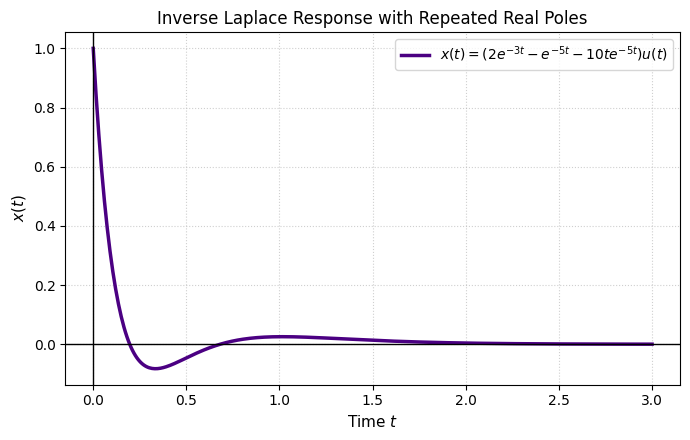

In [1]:
# Notebook: Inverse Laplace Transform via Partial Fraction Expansion (Repeated Real Poles)
# Example: X(s) = (s^2 + 2s + 5) / ((s + 3) * (s + 5)^2)

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SYMPY: Partial Fraction Expansion & Inverse Laplace ---
s = sp.Symbol('s')
t = sp.Symbol('t', real=True, positive=True)

# Define the transform X(s)
numerator = s**2 + 2*s + 5
denominator = (s + 3) * (s + 5)**2
X_s = numerator / denominator

print("1. Given Transform X(s):")
display(X_s)

# Perform Partial Fraction Expansion (PFE)
X_s_pfe = sp.apart(X_s, s)
print("Partial Fraction Expansion of X(s):")
display(X_s_pfe)

# Compute Inverse Laplace Transform
x_t = sp.inverse_laplace_transform(X_s, s, t)
print("\n2. Computed Inverse Transform x(t):")
display(x_t)


# --- 2. NUMPY & MATPLOTLIB: Time-domain response visualization ---
x_t_numeric = sp.lambdify(t, x_t, 'numpy')

t_vals = np.linspace(0, 3, 400)
x_vals = x_t_numeric(t_vals)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(t_vals, x_vals, color='indigo', lw=2.5, label=r'$x(t) = (2e^{-3t} - e^{-5t} - 10te^{-5t})u(t)$')

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel(r'Time $t$', fontsize=11)
ax.set_ylabel(r'$x(t)$', fontsize=11)
ax.set_title(r'Inverse Laplace Response with Repeated Real Poles', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', frameon=True)

plt.tight_layout()
plt.show()